✅ 환경 준비 완료
✅ 피처 목록 로드 완료 (27개 피처)
✅ 최적 파라미터 로드 완료
⚠️ 원본 검증셋 전수(약 800만 건)를 로드합니다.
Val Tune : 7,902,193 rows
✅ 앙상블 서브셋 모델 로드 완료 (10개 모델)
✅ 추가된 파라미터: scale_pos_weight = 3.0
✅ 트레인 서브셋 로드 완료: 10개
🚀 가중치 적용 모델 앙상블 학습 시작...
✅  10개 모델 학습 및 평가 완료.                                        

✨  앙상블 최종 VAL_TUNE PR-AUC = 0.12104 (참고용 - 최종 Test Metric 아님)
\n=========================================
📊 클래스 가중치(3.0) 적용 앙상블 결과

              UNDERBAGGING ENSEMBLE SUMMARY
  Final Ensemble PR-AUC: 0.12104

  서브셋별 VAL_TUNE PR-AUC:
    Subset 01: 0.11511
    Subset 02: 0.11119
    Subset 03: 0.11728
    Subset 04: 0.11383
    Subset 05: 0.11385
    Subset 06: 0.11146
    Subset 07: 0.11212
    Subset 08: 0.11168
    Subset 09: 0.10560
    Subset 10: 0.11519

  평균 (단순): 0.11273  ±  0.00302


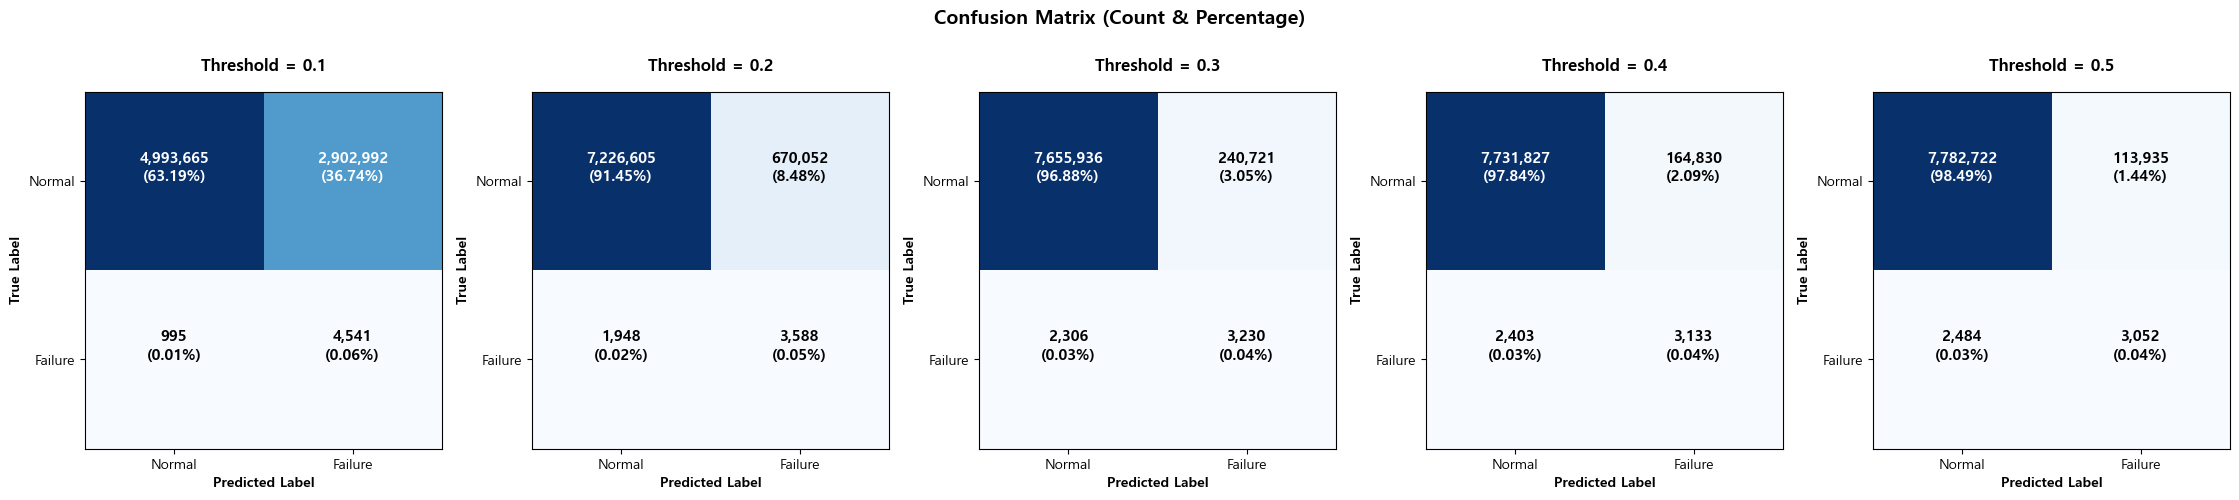

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))  # notebooks/research/ 에서 실행 시 루트 경로 참조

import pandas as pd
import joblib
import json
from pathlib import Path
from sklearn.metrics import classification_report

import config.train_config as cfg
from src.train_core import evaluate_saved_models, plot_shap_importance
from src.train_core import print_ensemble_summary, plot_subset_prauc, plot_confusion_matrix

print('✅ 환경 준비 완료')
from src.train_core import SubsetTrainer, UnderbaggingEnsemble
SAVE_DIR = Path(cfg.MODEL_SAVE_DIR)

if not SAVE_DIR.exists():
    raise FileNotFoundError(f"모델 저장 경로를 찾을 수 없습니다: {SAVE_DIR}")

# 피처 목록 로드
feat_path = SAVE_DIR / 'feature_cols.json'
with open(feat_path, 'r', encoding='utf-8') as f:
    FEATURE_COLS = json.load(f)

print(f"✅ 피처 목록 로드 완료 ({len(FEATURE_COLS)}개 피처)")

# 파라미터 로드
param_path = SAVE_DIR / 'best_params.json'
with open(param_path, 'r', encoding='utf-8') as f:
    best_params = json.load(f)

print(f"✅ 최적 파라미터 로드 완료")
# ── [검증 데이터 설정] ────────────────────────────────────────
USE_SAMPLED_VAL = False  # True: 샘플링된 파일 사용, False: 원본 전체 데이터(800만 건) 사용
# ────────────────────────────────────────────────────────────

VAL_FULL_PATH = str(Path(cfg.TRAIN_PATH).parent / "val_tune.parquet")

if USE_SAMPLED_VAL:
    val_path = cfg.VAL_TUNE_SAMPLED_PATH
    print(f"💡 샘플링된 검증셋을 로드합니다. ({Path(val_path).name})")
else:
    val_path = VAL_FULL_PATH
    print("⚠️ 원본 검증셋 전수(약 800만 건)를 로드합니다.")

df_val_tune = pd.read_parquet(val_path)
print(f"Val Tune : {len(df_val_tune):,} rows")

# 모델 로드
models = []
for pkl_file in sorted(SAVE_DIR.glob('subset_*.pkl')):
    models.append(joblib.load(pkl_file))
    
print(f"✅ 앙상블 서브셋 모델 로드 완료 ({len(models)}개 모델)")

# 1. 로드된 최적 파라미터에 클래스 가중치(scale_pos_weight) 3.0 추가
experiment_params = best_params.copy()
experiment_params['scale_pos_weight'] = 3.0

print(f"✅ 추가된 파라미터: scale_pos_weight = {experiment_params['scale_pos_weight']}")

# 2. 학습용 트레인 서브셋 로드 (새로운 모델을 훈련해야 하므로 필요)
subset_dir = Path(cfg.SUBSET_DIR)
subset_files = sorted(list(subset_dir.glob("subset_*.parquet")))
df_train_list = [pd.read_parquet(f) for f in subset_files]
print(f"✅ 트레인 서브셋 로드 완료: {len(df_train_list)}개")

# 3. 새로운 파라미터로 모델 새로 학습
print("🚀 가중치 적용 모델 앙상블 학습 시작...")
trainer = SubsetTrainer(lgbm_params=experiment_params, target_col=cfg.TARGET_COL)
experiment_ens = UnderbaggingEnsemble(trainer=trainer)

# df_val_tune은 기존 목차에서 로드한 변수를 그대로 재사용
exp_result = experiment_ens.fit(
    df_train_list=df_train_list, 
    df_val_tune=df_val_tune, 
    feature_cols=FEATURE_COLS, 
    target_col=cfg.TARGET_COL
)

# 4. 실험 결과 출력 및 비교
print('\\n=========================================')
print('📊 클래스 가중치(3.0) 적용 앙상블 결과')
print('=========================================')
print_ensemble_summary(exp_result)
plot_confusion_matrix(exp_result, cfg)
